In [1]:
import random
import numpy as np
from matplotlib import pyplot as plt

### **Curve Fitting using Genetic Algorithm**
To use the genetic algorithm, firstly we have to determine the type of chromosomes for this problem which is obviously an array of real numbers.

#### **Fitness Function**
$a$ is obtained value

$b$ is actual value

$fitness = \frac{1}{n} \sum_{i=1} ^{n} (\frac{a_i - b_i}{b_i} * 100) $ 


In [2]:
class Chromosome:
    def __init__(self, n:int, s:int, e:int) -> None:
        self.s = s
        self.e = e
        self.n = n
        self.coefficient = list(random.uniform(s, e) for _ in range(n+1))
        self.fitness = s
        self.calc_fitness()
    
    def mutation(self, alpha =.99) -> None:
        if random.random() < alpha:
            a = random.randint(0,self.n)
            b = random.randint(0,self.n)
                     
            self.coefficient[a] = self.e - self.coefficient[a]
            self.coefficient[b] = self.e - self.coefficient[b]
            if self.coefficient[a] > self.e:
                self.coefficient[a] -= self.e
            if self.coefficient[a] < self.s:
                self.coefficient[a] += self.s    

            if self.coefficient[b] > self.e:
                self.coefficient[b] -= self.e
            if self.coefficient[b] < self.s:
                self.coefficient[b] += self.s    
                
        self.calc_fitness()
    
    def calc_fitness(self) -> int:
        error = 0
        for i in range(points_num):
            x = points[i]
            res = 0
            for j in range(self.n+1):
                res += self.coefficient[j] * (x[0]**j)
            if res != 0:
                error += abs((x[1] - res) / res)*100
            
        error /= points_num
        self.fitness = error
        
    def plot(self):
        x = np.linspace(-20, 20, 100)
        y = 0    
        for j in range(self.n+1):
            y += self.coefficient[j] * (x**j)

        plt.plot(x, y, label='Curve')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Curve')
        plt.grid(True)
        plt.legend()
        plt.show()

#### **Mutation**

##### *How to mutate?*

select two gene indexes and change their values:
- The new value is equal to the maximum valid value minus present value.
 
    The more likely the mutation is, the more the exploration capability will increase. So $\alpha = 0.99$ .

#### **How Crossover Works?**

In [3]:
def cross_over(par1 : Chromosome, par2:Chromosome, alpha:int = 0.5) -> Chromosome:
    child = Chromosome(par1.n, par1.s, par1.e)
    
    for i in range(par1.n//4):
        child.coefficient[i] = par1.coefficient[i]

    for i in range(par1.n//4, par1.n):
        child.coefficient[i] = alpha * (par1.coefficient[i] + par2.coefficient[i])
            
    child.calc_fitness()
    return child

#### **Selection ?**
- *`Truncation Selection`* = sort the population based on *fitness* and then randomly select some members from among the top percentage members of the population.

#### **Replacement ?**
- *`Steady State Replacement`* = Keeping the majority of the parent population and replacing the best offspring produced with part of the parent

In [4]:
def GA(pop_size, n, s, e) -> Chromosome:
    population = [Chromosome(n, s, e) for _ in range(pop_size)]

    count = 0
    perv = 0
    population.sort(key = lambda x :x.fitness)
    
    while (True):
        children = []        
        sample = population[:int(pop_size*.55)]
        for _ in range(pop_size):
            parents = random.choices(sample, k = 2)
            child = cross_over(*parents)
            child.mutation()
            children.append(child)
            
            child2 = (cross_over(parents[1], parents[0]))
            child2.mutation()
            children.append(child2)
            
            
        children.sort(key = lambda x :x.fitness)

        population = population[ :pop_size-1] + children[ :1] 
        """ trade-off between exploration & exploitation """
        population.sort(key = lambda x :x.fitness)

        print('best fitness: %' , round(population[0].fitness, 3), "\t \t worse fitness: %" , round(population[-1].fitness, 3) ,sep='')
        
        if (population[0].fitness == perv):
            count +=1
        else:
            count = 0
            perv = population[0].fitness
        
        if (count > 100):
            break
        
    return population[0]      

#### **Test Cases**
test case 1

In [5]:
points = list()
x, y = [], []
with open('.\\CurveFitting_test1.txt', 'r') as f:
    lines = f.readlines()

count=1
for line in lines:
    l= line.split()
    
    if count==1:
        n = int(l[0])
    elif count==2:
        s, e = float(l[0]), float(l[1])
    elif count==3:
        points_num = int(l[0])
    else:
        points.append([float(l[0]), float(l[1])])
        x.append(float(l[0]))
        y.append(float(l[1]))
    count+=1

In [6]:
res = GA(200, n, s, e)

best fitness: %21.944	 	 worse fitness: %1234.706
best fitness: %15.016	 	 worse fitness: %594.211
best fitness: %15.016	 	 worse fitness: %582.419
best fitness: %15.016	 	 worse fitness: %547.418
best fitness: %15.016	 	 worse fitness: %522.487
best fitness: %15.016	 	 worse fitness: %441.205
best fitness: %13.134	 	 worse fitness: %429.059
best fitness: %13.134	 	 worse fitness: %391.958
best fitness: %13.134	 	 worse fitness: %388.549
best fitness: %13.134	 	 worse fitness: %358.967
best fitness: %13.134	 	 worse fitness: %340.838
best fitness: %13.134	 	 worse fitness: %334.615
best fitness: %13.134	 	 worse fitness: %317.492
best fitness: %13.134	 	 worse fitness: %314.423
best fitness: %13.134	 	 worse fitness: %300.017
best fitness: %13.134	 	 worse fitness: %244.585
best fitness: %13.134	 	 worse fitness: %239.982
best fitness: %13.134	 	 worse fitness: %237.593
best fitness: %13.134	 	 worse fitness: %222.485
best fitness: %13.134	 	 worse fitness: %213.004
best fitness: %13.1

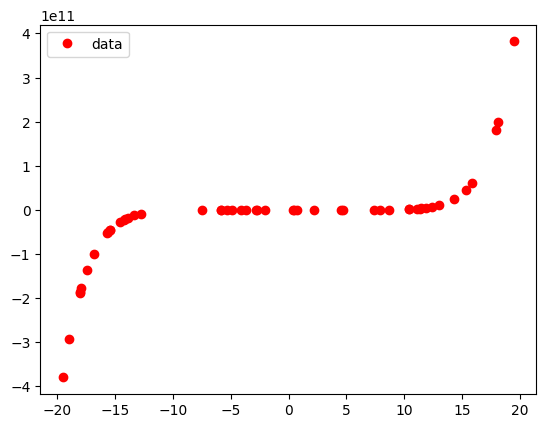

In [7]:
plt.plot(x,y, 'o', color ='red', label ="data")
plt.legend()
plt.show()

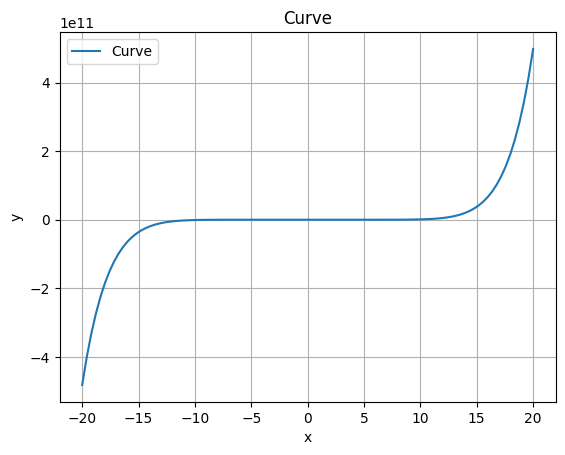

In [8]:
res.plot()

test case 2

In [9]:
points = list()
x, y = [], []
with open('.\\CurveFitting_test2.txt', 'r') as f:
    lines = f.readlines()

count=1
for line in lines:
    l= line.split()
    
    if count==1:
        n = int(l[0])
    elif count==2:
        s, e = float(l[0]), float(l[1])
    elif count==3:
        points_num = int(l[0])
    else:
        points.append([float(l[0]), float(l[1])])
        x.append(float(l[0]))
        y.append(float(l[1]))
    count+=1

res = GA(200, n, s, e)

best fitness: %72.136	 	 worse fitness: %3065.648
best fitness: %39.767	 	 worse fitness: %2986.271
best fitness: %39.314	 	 worse fitness: %1711.618
best fitness: %39.314	 	 worse fitness: %1698.178
best fitness: %39.314	 	 worse fitness: %1494.345
best fitness: %34.71	 	 worse fitness: %1448.298
best fitness: %29.381	 	 worse fitness: %1427.468
best fitness: %29.381	 	 worse fitness: %1408.526
best fitness: %29.381	 	 worse fitness: %1391.99
best fitness: %29.381	 	 worse fitness: %1382.661
best fitness: %29.381	 	 worse fitness: %1295.616
best fitness: %29.381	 	 worse fitness: %1271.677
best fitness: %28.142	 	 worse fitness: %1262.913
best fitness: %28.142	 	 worse fitness: %1066.291
best fitness: %26.739	 	 worse fitness: %999.011
best fitness: %26.739	 	 worse fitness: %899.484
best fitness: %26.739	 	 worse fitness: %873.518
best fitness: %26.739	 	 worse fitness: %815.567
best fitness: %25.158	 	 worse fitness: %806.963
best fitness: %25.158	 	 worse fitness: %774.043
best fit

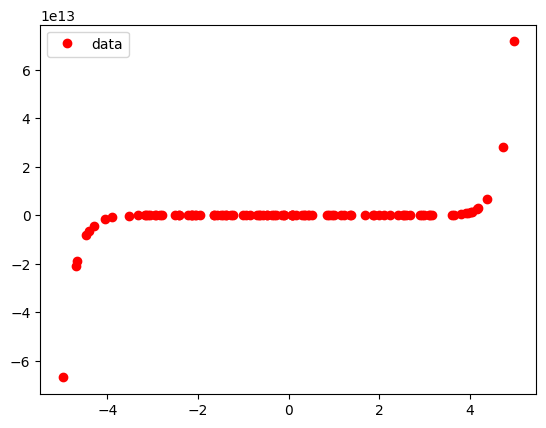

In [10]:
plt.plot(x,y, 'o', color ='red', label ="data")
plt.legend()
plt.show()

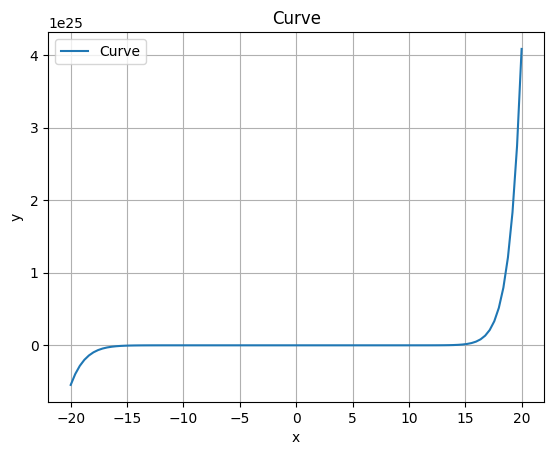

In [11]:
res.plot()

test case 3

In [12]:
points = list()
x, y = [], []
with open('.\\CurveFitting_test3.txt', 'r') as f:
    lines = f.readlines()

count=1
for line in lines:
    l= line.split()
    
    if count==1:
        n = int(l[0])
    elif count==2:
        s, e = float(l[0]), float(l[1])
    elif count==3:
        points_num = int(l[0])
    else:
        points.append([float(l[0]), float(l[1])])
        x.append(float(l[0]))
        y.append(float(l[1]))
    count+=1

res = GA(200, n, s, e)

best fitness: %65.364	 	 worse fitness: %1392.271
best fitness: %53.468	 	 worse fitness: %912.187
best fitness: %43.851	 	 worse fitness: %877.118
best fitness: %43.851	 	 worse fitness: %864.262
best fitness: %43.851	 	 worse fitness: %779.726
best fitness: %43.851	 	 worse fitness: %710.219
best fitness: %43.851	 	 worse fitness: %648.816
best fitness: %43.851	 	 worse fitness: %575.541
best fitness: %43.851	 	 worse fitness: %565.829
best fitness: %43.851	 	 worse fitness: %551.989
best fitness: %43.851	 	 worse fitness: %536.178
best fitness: %43.851	 	 worse fitness: %533.903
best fitness: %34.603	 	 worse fitness: %531.764
best fitness: %34.603	 	 worse fitness: %531.038
best fitness: %34.603	 	 worse fitness: %489.836
best fitness: %34.603	 	 worse fitness: %457.777
best fitness: %34.603	 	 worse fitness: %453.588
best fitness: %34.603	 	 worse fitness: %443.682
best fitness: %34.603	 	 worse fitness: %429.441
best fitness: %34.603	 	 worse fitness: %424.716
best fitness: %34.6

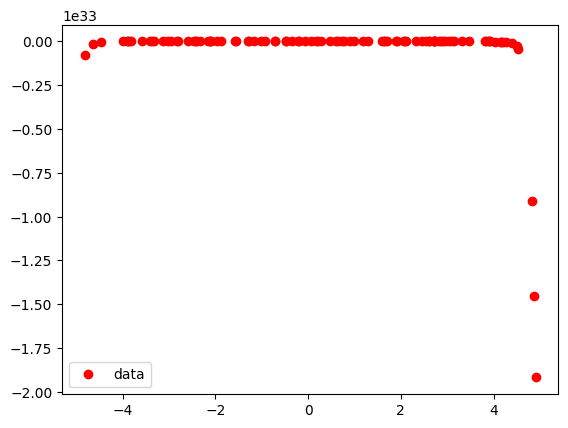

In [13]:
plt.plot(x,y, 'o', color ='red', label ="data")
plt.legend()
plt.show()

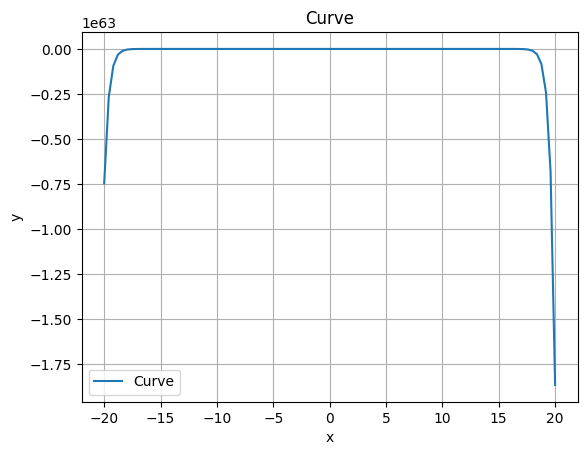

In [14]:
res.plot()

test case 4

In [18]:
points = list()
x, y = [], []
with open('.\\CurveFitting_test4.txt', 'r') as f:
    lines = f.readlines()

count=1
for line in lines:
    l= line.split()
    
    if count==1:
        n = int(l[0])
    elif count==2:
        s, e = float(l[0]), float(l[1])
    elif count==3:
        points_num = int(l[0])
    else:
        points.append([float(l[0]), float(l[1])])
        x.append(float(l[0]))
        y.append(float(l[1]))
    count+=1

res = GA(200, n, s, e)

best fitness: %43.422	 	 worse fitness: %4426.499
best fitness: %43.422	 	 worse fitness: %1521.854
best fitness: %43.422	 	 worse fitness: %1050.798
best fitness: %43.422	 	 worse fitness: %1009.105
best fitness: %43.422	 	 worse fitness: %985.825
best fitness: %36.082	 	 worse fitness: %938.745
best fitness: %36.082	 	 worse fitness: %790.739
best fitness: %36.082	 	 worse fitness: %770.401
best fitness: %36.082	 	 worse fitness: %638.081
best fitness: %36.082	 	 worse fitness: %562.475
best fitness: %36.082	 	 worse fitness: %451.719
best fitness: %36.082	 	 worse fitness: %419.309
best fitness: %36.082	 	 worse fitness: %413.069
best fitness: %36.082	 	 worse fitness: %382.493
best fitness: %36.082	 	 worse fitness: %359.925
best fitness: %36.082	 	 worse fitness: %358.688
best fitness: %36.082	 	 worse fitness: %354.432
best fitness: %36.082	 	 worse fitness: %331.309
best fitness: %36.082	 	 worse fitness: %329.443
best fitness: %36.082	 	 worse fitness: %294.619
best fitness: %3

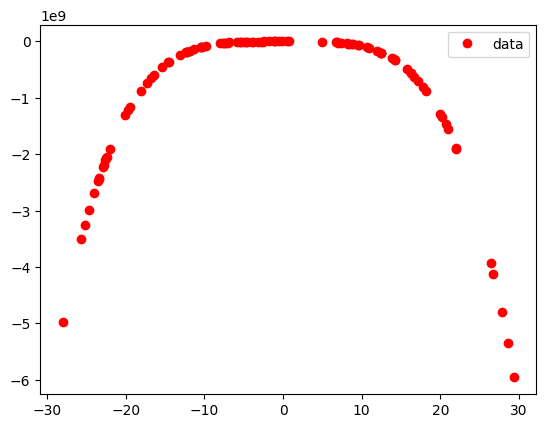

In [16]:
plt.plot(x,y, 'o', color ='red', label ="data")
plt.legend()
plt.show()

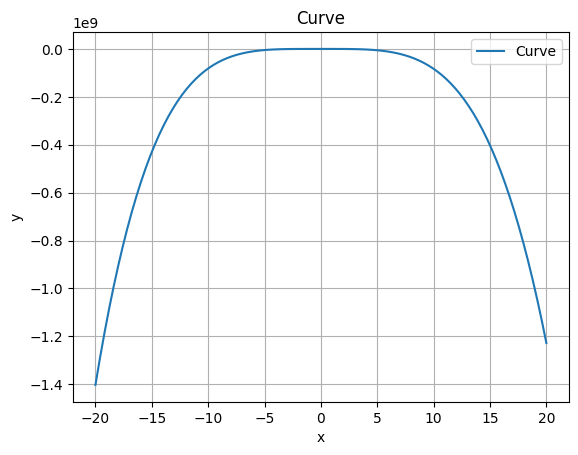

In [17]:
res.plot()
